## 1. Drop Unnecessary Columns

In [52]:
import sys
import pandas as pd
sys.path.append('..')

from src.db_connector import fetch_data

dataset = fetch_data("SELECT * FROM e_commerce_dataset_e_comm")

dataset.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,160
1,50002,1,,Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0,1,0,121
2,50003,1,,Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0,1,3,120
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134
4,50005,1,0,Phone,1,12,CC,Male,,3,Mobile,5,Single,3,0,11,1,1,3,130


In [53]:
import pandas as pd

dataset = dataset.drop(columns=['CustomerID'])
dataset.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,160
1,1,,Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0,1,0,121
2,1,,Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0,1,3,120
3,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134
4,1,0,Phone,1,12,CC,Male,,3,Mobile,5,Single,3,0,11,1,1,3,130


## 2. Converting String Data to Numeric

In [54]:
cols_to_convert = [
    'Tenure', 
    'WarehouseToHome', 
    'HourSpendOnApp', 
    'OrderAmountHikeFromlastYear', 
    'CouponUsed', 
    'OrderCount', 
    'DaySinceLastOrder'
]

for col in cols_to_convert:
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

dataset[cols_to_convert].isnull().sum()

Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

In [55]:
dataset.isnull().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [56]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5366 non-null   float64
 2   PreferredLoginDevice         5630 non-null   str    
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5379 non-null   float64
 5   PreferredPaymentMode         5630 non-null   str    
 6   Gender                       5630 non-null   str    
 7   HourSpendOnApp               5375 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   str    
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   str    
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain                     

## 3. Split Dataset

In [57]:
from sklearn.model_selection import train_test_split

X = dataset.drop('Churn', axis=1)
y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
X_train.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1787,9.0,Computer,3,16.0,Credit Card,Male,2.0,3,Fashion,1,Single,2,0,14.0,8.0,9.0,7.0,200
2147,6.0,Computer,3,13.0,Debit Card,Female,1.0,3,Laptop & Accessory,4,Married,1,0,17.0,0.0,1.0,2.0,143
1717,8.0,Mobile Phone,1,15.0,Debit Card,Male,3.0,4,Laptop & Accessory,4,Single,10,0,19.0,0.0,1.0,0.0,165
2292,15.0,Mobile Phone,3,11.0,Debit Card,Male,3.0,3,Fashion,4,Single,10,1,19.0,7.0,7.0,7.0,184
5578,12.0,Computer,1,13.0,Debit Card,Male,4.0,5,Laptop & Accessory,3,Married,4,0,12.0,3.0,8.0,8.0,178


In [59]:
y_train.head()

1787    0
2147    0
1717    0
2292    1
5578    0
Name: Churn, dtype: int64

## 4. Handle Missing Value

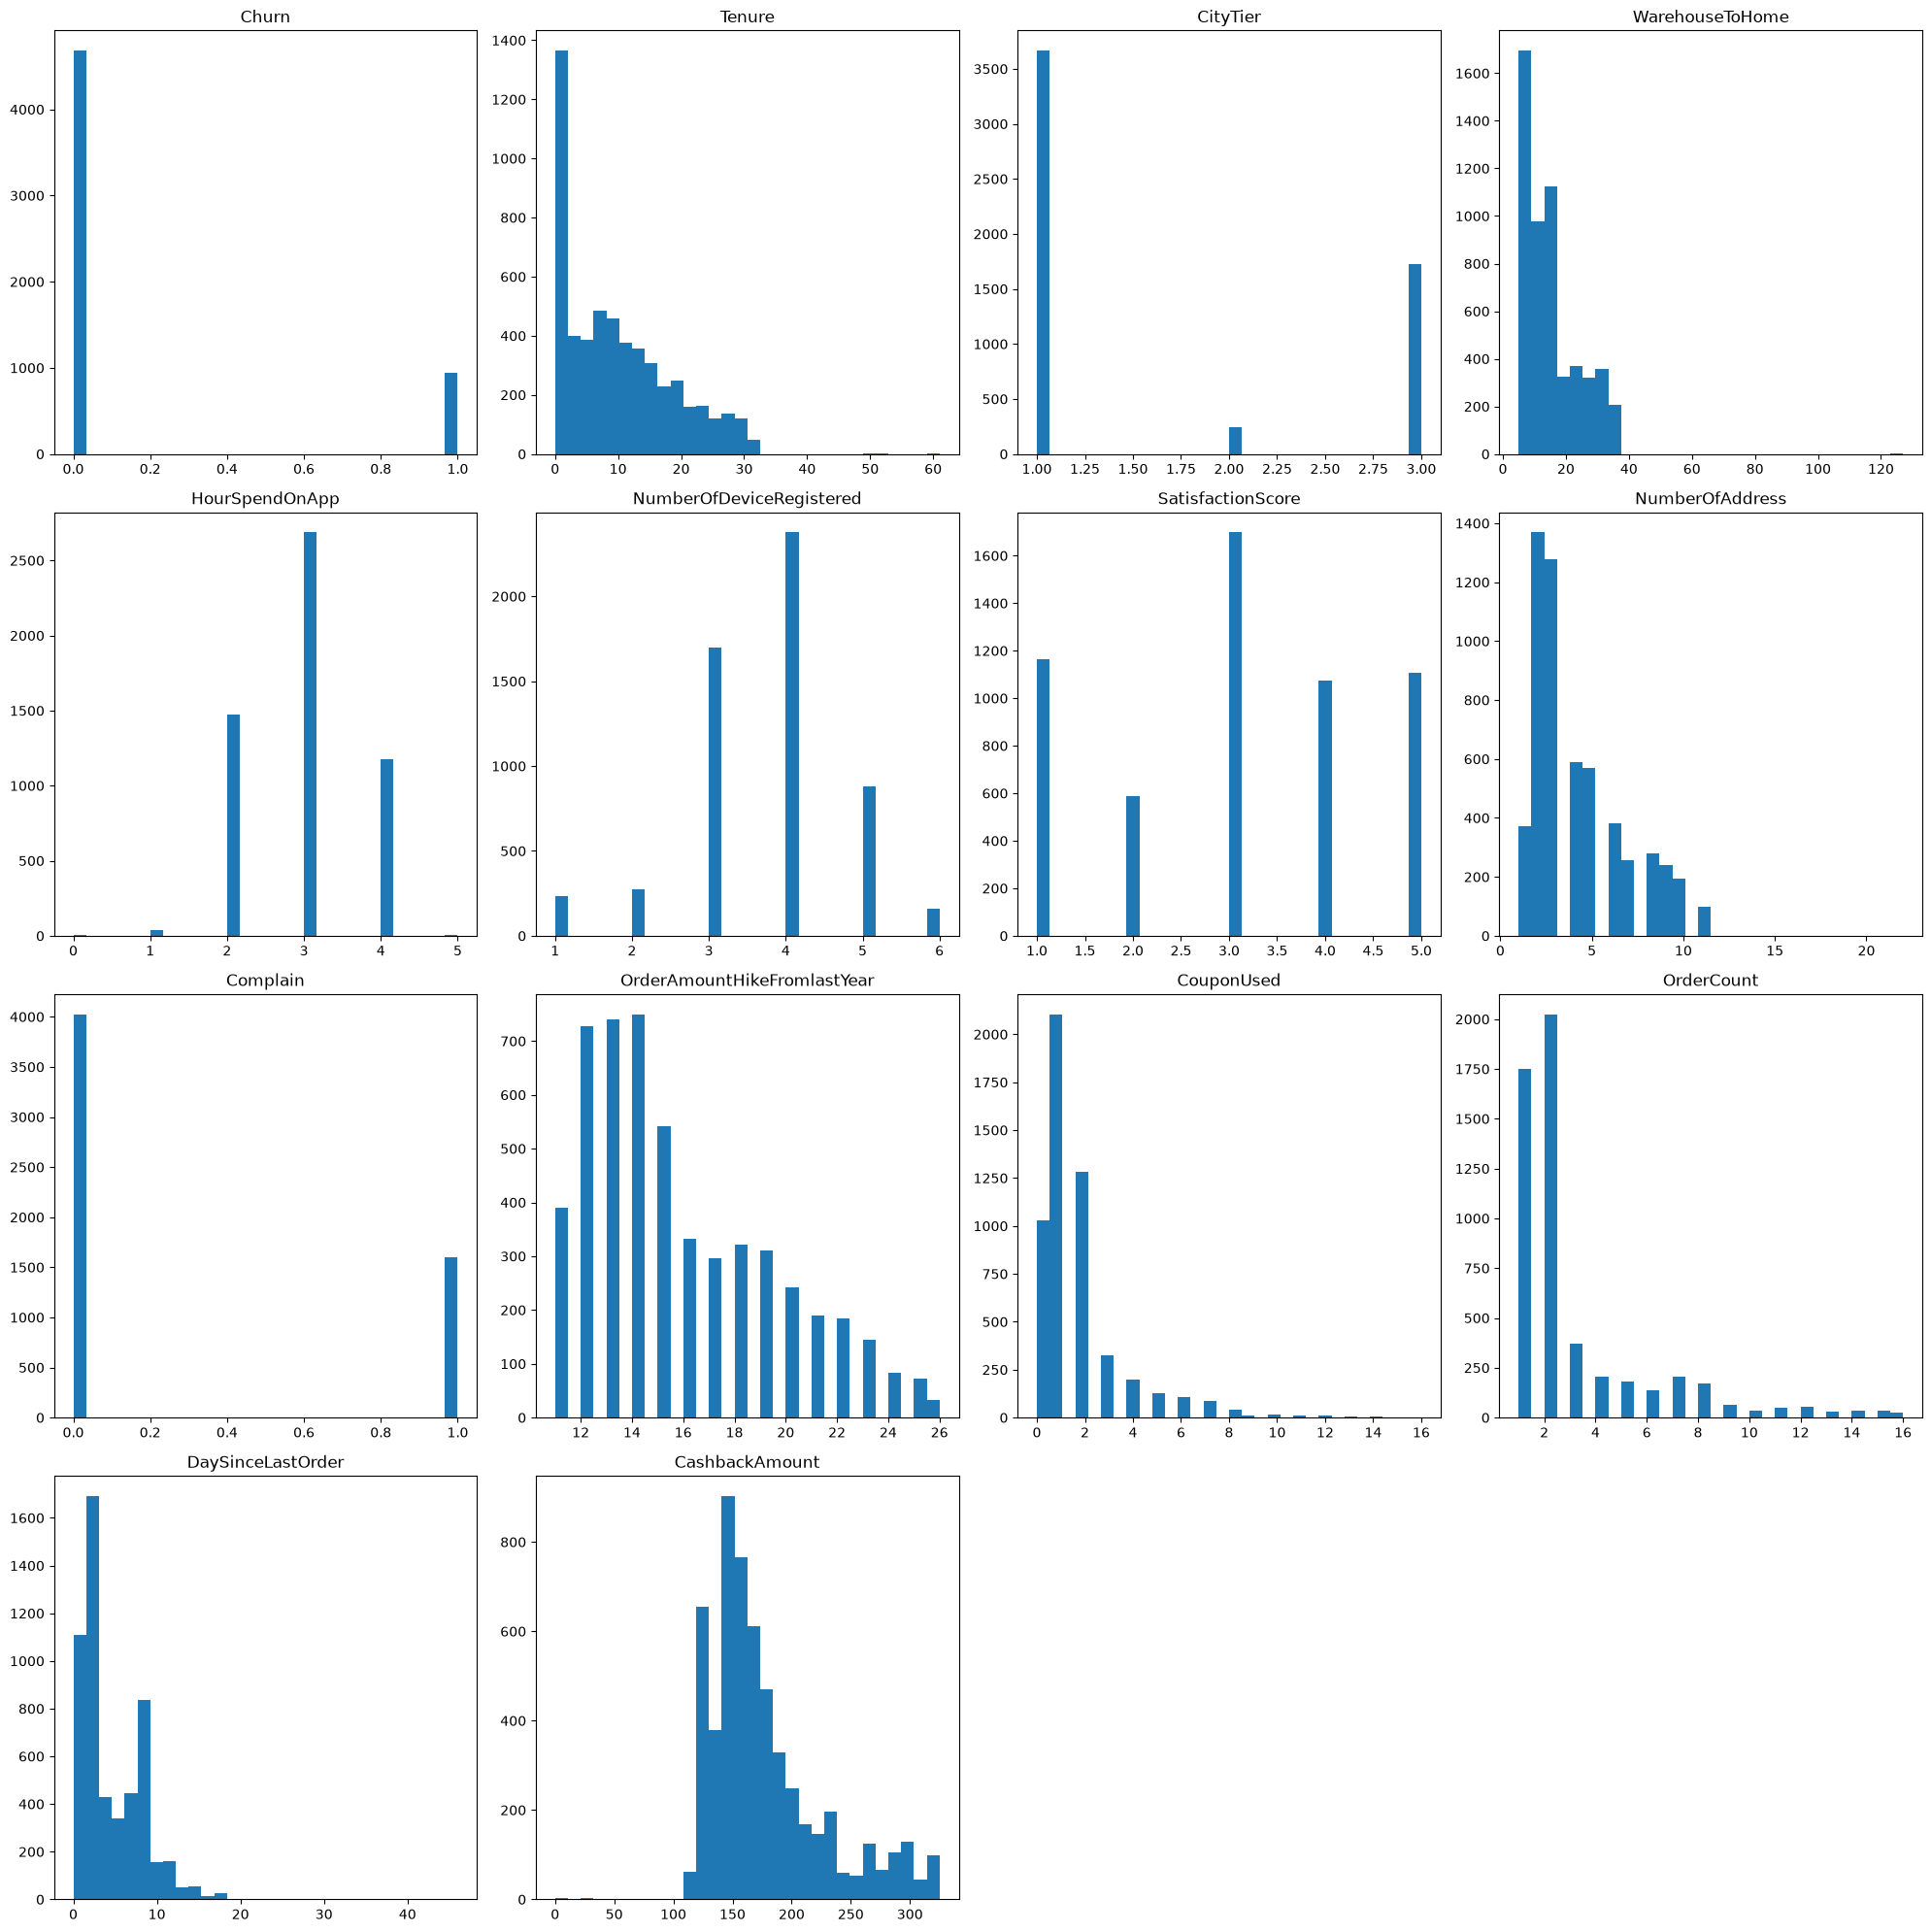

In [60]:
import math
import matplotlib.pyplot as plt

num_cols = dataset.select_dtypes(include='number').columns
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(dataset[col], bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [61]:
dataset.isnull().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [62]:
## Note: 
## Tenure, WarehouseToHome, OrderAmountHikeFromlastYear, CoupunUsed, OrderCount, DaySinceLastOrder have right skewed 
## HourSpendOnApp normal skewed 

# 1. Impute with 0 (assuming new customers/no prior activity)
zero_cols = ['Tenure', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount']
X_train[zero_cols] = X_train[zero_cols].fillna(0)
X_test[zero_cols] = X_test[zero_cols].fillna(0)

# 2. Impute with -1 (indicating 'never ordered')
X_train['DaySinceLastOrder'] = X_train['DaySinceLastOrder'].fillna(-1)
X_test['DaySinceLastOrder'] = X_test['DaySinceLastOrder'].fillna(-1)

# 3. Impute distance based on CityTier median (computed purely from X_train)
train_city_median = X_train.groupby('CityTier')['WarehouseToHome'].transform('median')
X_train['WarehouseToHome'] = X_train['WarehouseToHome'].fillna(train_city_median)

# Apply X_train's city medians to X_test (fallback to overall median if city is missing)
test_city_median = X_test['CityTier'].map(X_train.groupby('CityTier')['WarehouseToHome'].median())
overall_dist_median = X_train['WarehouseToHome'].median()
X_test['WarehouseToHome'] = X_test['WarehouseToHome'].fillna(test_city_median).fillna(overall_dist_median)

# 4. Impute app usage with overall median
hour_median = X_train['HourSpendOnApp'].median()
X_train['HourSpendOnApp'] = X_train['HourSpendOnApp'].fillna(hour_median)
X_test['HourSpendOnApp'] = X_test['HourSpendOnApp'].fillna(hour_median)

# Verify missing values
print(X_train.isnull().sum().sum(), "nulls left in Train")
print(X_test.isnull().sum().sum(), "nulls left in Test")

0 nulls left in Train
0 nulls left in Test


## 5. Encoding

In [63]:
X_train.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1787,9.0,Computer,3,16.0,Credit Card,Male,2.0,3,Fashion,1,Single,2,0,14.0,8.0,9.0,7.0,200
2147,6.0,Computer,3,13.0,Debit Card,Female,1.0,3,Laptop & Accessory,4,Married,1,0,17.0,0.0,1.0,2.0,143
1717,8.0,Mobile Phone,1,15.0,Debit Card,Male,3.0,4,Laptop & Accessory,4,Single,10,0,19.0,0.0,1.0,0.0,165
2292,15.0,Mobile Phone,3,11.0,Debit Card,Male,3.0,3,Fashion,4,Single,10,1,19.0,7.0,7.0,7.0,184
5578,12.0,Computer,1,13.0,Debit Card,Male,4.0,5,Laptop & Accessory,3,Married,4,0,12.0,3.0,8.0,8.0,178


In [64]:
# One Hot Encoding 
X_train = pd.get_dummies(X_train, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus'], drop_first=True)

bool_cols = X_train.select_dtypes(include=['bool']).columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [65]:
X_train.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
1787,9.0,3,16.0,2.0,3,1,2,0,14.0,8.0,...,0,0,1,0,0,0,0,0,0,1
2147,6.0,3,13.0,1.0,3,4,1,0,17.0,0.0,...,0,0,0,0,1,0,0,0,1,0
1717,8.0,1,15.0,3.0,4,4,10,0,19.0,0.0,...,0,0,1,0,1,0,0,0,0,1
2292,15.0,3,11.0,3.0,3,4,10,1,19.0,7.0,...,0,0,1,0,0,0,0,0,0,1
5578,12.0,1,13.0,4.0,5,3,4,0,12.0,3.0,...,0,0,1,0,1,0,0,0,1,0


## 6. Handling Imbalanced

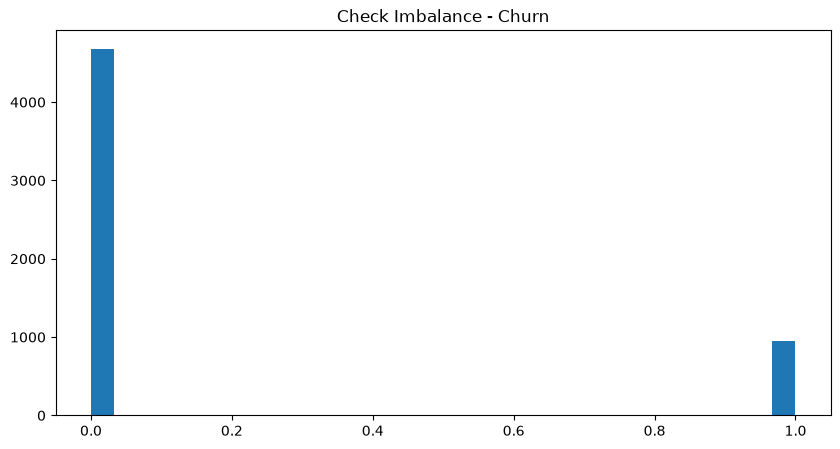

In [66]:
col = 'Churn'  
plt.figure(figsize=(10, 5))
plt.hist(dataset[col].dropna(), bins=30)
plt.title('Check Imbalance - Churn')
plt.show()

In [67]:
# Import SMOTE from imbalanced-learn library
from imblearn.over_sampling import SMOTE

# Initialize SMOTE (set random_state for reproducibility)
smote = SMOTE(random_state=42)

# Apply SMOTE strictly to the training data to prevent data leakage
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Verify the class distribution before and after oversampling
print("Class Distribution Before Smote")
print(y_train.value_counts())

print("\nClass Distribution After Smote")
print(y_train_smote.value_counts())


Class Distribution Before Smote
Churn
0    3746
1     758
Name: count, dtype: int64

Class Distribution After Smote
Churn
0    3746
1    3746
Name: count, dtype: int64


## 7. Normalization

In [69]:
from sklearn.preprocessing import RobustScaler

# Define pure numerical columns for scaling
cols_to_scale = [
    'Tenure', 
    'WarehouseToHome', 
    'HourSpendOnApp', 
    'NumberOfDeviceRegistered', 
    'NumberOfAddress', 
    'OrderAmountHikeFromlastYear', 
    'CouponUsed', 
    'OrderCount', 
    'DaySinceLastOrder', 
    'CashbackAmount'
]

# Initialize the RobustScaler
robust_scaler = RobustScaler()

# Fit on X_train to prevent data leakage, then transform both train and test sets
X_train[cols_to_scale] = robust_scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = robust_scaler.transform(X_test[cols_to_scale])

# Verify the scaled features
X_train.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
1787,0.071429,3,0.272727,-1.0,-1.0,1,-0.25,0,0.0,7.0,...,0,0,1,0,0,0,0,0,0,1
2147,-0.142857,3,0.000000,-2.0,-1.0,4,-0.50,0,0.6,-1.0,...,0,0,0,0,1,0,0,0,1,0
1717,0.000000,1,0.181818,0.0,0.0,4,1.75,0,1.0,-1.0,...,0,0,1,0,1,0,0,0,0,1
2292,0.500000,3,-0.181818,0.0,-1.0,4,1.75,1,1.0,6.0,...,0,0,1,0,0,0,0,0,0,1
5578,0.285714,1,0.000000,1.0,1.0,3,0.25,0,-0.4,2.0,...,0,0,1,0,1,0,0,0,1,0


## 8. Save the Result

In [70]:
import os

# Create directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save the preprocessed and resampled datasets to CSV
X_train_smote.to_csv('../data/processed/X_train_preprocessed.csv', index=False)
X_test.to_csv('../data/processed/X_test_preprocessed.csv', index=False)
y_train_smote.to_csv('../data/processed/y_train_preprocessed.csv', index=False)
y_test.to_csv('../data/processed/y_test_preprocessed.csv', index=False)

print("All preprocessed data successfully saved to 'data/processed/' directory!")

All preprocessed data successfully saved to 'data/processed/' directory!
